<a href="https://colab.research.google.com/github/Vinuthnachakravarthy/DevStudent-2601716-/blob/main/Batch_1_9_2_session.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)

In [ ]:
df = pd.read_csv("used_cars_messy.csv")
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,224,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,1803,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,2728,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,14160,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0


In [ ]:
df.shape

(15661, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15661 entries, 0 to 15660
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15661 non-null  int64  
 1   car_name           15661 non-null  object 
 2   brand              15661 non-null  object 
 3   model              15661 non-null  object 
 4   vehicle_age        15661 non-null  int64  
 5   km_driven          15661 non-null  object 
 6   seller_type        15661 non-null  object 
 7   fuel_type          15661 non-null  object 
 8   transmission_type  15661 non-null  object 
 9   mileage            14376 non-null  object 
 10  engine             13792 non-null  float64
 11  max_power          14862 non-null  float64
 12  seats              15218 non-null  float64
 13  selling_price      15503 non-null  float64
dtypes: float64(4), int64(2), object(8)
memory usage: 1.7+ MB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,1285


In [ ]:
df.isnull().sum() * 100/ df.shape[0]

,0
Unnamed: 0,0.000000
car_name,0.000000
brand,0.000000
model,0.000000
vehicle_age,0.000000
km_driven,0.000000
seller_type,0.000000
fuel_type,0.000000
transmission_type,0.000000
mileage,8.205095


In [ ]:
1281*100/15661

8.179554306876955

In [ ]:
df.duplicated().sum()

np.int64(169)

In [ ]:
df[df.duplicated(keep=False)].sort_values('car_name').head(20)

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
9347,1210,Audi A4,Audi,A4,9,23994,Dealer,Diesel,Automatic,17.11,NaN,174.33,5.0,1275000.0
5920,1210,Audi A4,Audi,A4,9,23994,Dealer,Diesel,Automatic,17.11,NaN,174.33,5.0,1275000.0
13398,6871,Audi A4,Audi,A4,4,53700,Individual,Diesel,Automatic,18.25,1968.0,187.74,5.0,1760000.0
3642,6871,Audi A4,Audi,A4,4,53700,Individual,Diesel,Automatic,18.25,1968.0,187.74,5.0,1760000.0
867,16053,BMW 6,BMW,6,3,11000,Dealer,Diesel,Automatic,17.09,2993.0,NaN,4.0,5600000.0
8441,16053,BMW 6,BMW,6,3,11000,Dealer,Diesel,Automatic,17.09,2993.0,NaN,4.0,5600000.0
4958,11969,BMW X5,BMW,X5,7,68000,Dealer,Diesel,Automatic,11.7,2993.0,245.00,5.0,3200000.0
3709,11969,BMW X5,BMW,X5,7,68000,Dealer,Diesel,Automatic,11.7,2993.0,245.00,5.0,3200000.0
4973,7216,Datsun GO,Datsun,GO,4,23142,Dealer,Petrol,Manual,NaN,1198.0,67.00,5.0,360000.0
11616,7216,Datsun GO,Datsun,GO,4,23142,Dealer,Petrol,Manual,NaN,1198.0,67.00,5.0,360000.0


In [ ]:
cat_cols = ['car_name', 'brand', 'seller_type', 'fuel_type', 'transmission_type']

for col in cat_cols:
    unique_vals = df[col].unique()
    print(f"\n{col} {len(unique_vals)} unique values): ")
    print(sorted(unique_vals))


car_name 121 unique values): 
['Audi A4', 'Audi A6', 'Audi A8', 'Audi Q7', 'BMW 3', 'BMW 5', 'BMW 6', 'BMW 7', 'BMW X1', 'BMW X3', 'BMW X4', 'BMW X5', 'BMW Z4', 'Bentley Continental', 'Datsun GO', 'Datsun RediGO', 'Datsun redi-GO', 'Ferrari GTC4Lusso', 'Force Gurkha', 'Ford Aspire', 'Ford Ecosport', 'Ford Endeavour', 'Ford Figo', 'Ford Freestyle', 'Honda Amaze', 'Honda CR', 'Honda CR-V', 'Honda City', 'Honda Civic', 'Honda Jazz', 'Honda WR-V', 'Hyundai Aura', 'Hyundai Creta', 'Hyundai Elantra', 'Hyundai Grand', 'Hyundai Santro', 'Hyundai Tucson', 'Hyundai Venue', 'Hyundai Verna', 'Hyundai i10', 'Hyundai i20', 'ISUZU MUX', 'Isuzu D-Max', 'Isuzu MUX', 'Jaguar F-PACE', 'Jaguar XE', 'Jaguar XF', 'Jeep Compass', 'Jeep Wrangler', 'Kia Carnival', 'Kia Seltos', 'Land Rover Rover', 'Lexus ES', 'Lexus NX', 'Lexus RX', 'MG Hector', 'Mahindra Alturas', 'Mahindra Bolero', 'Mahindra KUV', 'Mahindra KUV100', 'Mahindra Marazzo', 'Mahindra Scorpio', 'Mahindra Thar', 'Mahindra XUV300', 'Mahindra XUV500

In [ ]:
print(df['km_driven'].dtype)

object


In [ ]:
print(df['km_driven'].sample(20).tolist())

['60000', '68000', '35000', '100000', '66000', '62000', '43000', '21860', '51000', '45864', '110000', '61500', '29000', '97000', '89000', '35000', '38000', '17000', '50000', '14000']


In [ ]:
list1 = df['km_driven'].sample(100).tolist()
#list1[0] + 10000

In [ ]:
print(df['mileage'].dtype)

object


In [ ]:
df['mileage'].sample(10).tolist()

['19.67', nan, '25.5', '19.01', '17.3', '16.55', nan, '22.54', '18.6', '20.51']

In [ ]:
df[df['km_driven'].astype(str).str.contains('kms')]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
80,4871,Mahindra XUV500,Mahindra,XUV500,6,42000 kms,Dealer,Diesel,Manual,15.1,2179.0,140.00,7.0,950000.0
244,15186,Renault Duster,Renault,Duster,5,62000 kms,Individual,Diesel,Manual,19.87,1461.0,83.80,5.0,700000.0
324,2767,Hyundai i20,Hyundai,i20,9,40000 kms,Dealer,Diesel,Manual,21.9,1396.0,NaN,5.0,435000.0
370,18113,Ford Aspire,Ford,Aspire,5,43652 kms,Dealer,Petrol,Manual,18.16,1196.0,86.80,5.0,430000.0
721,3117,Honda City,Honda,City,10,100000 kms,Individual,Petrol,Manual,17.0,1497.0,118.00,5.0,380000.0
1077,16806,Hyundai Creta,Hyundai,Creta,6,52000 kms,Dealer,Diesel,Manual,21.38,1396.0,88.70,5.0,925000.0
1316,5580,Maruti Swift Dzire,Maruti,Swift Dzire,7,91000 kms,Dealer,Diesel,Manual,23.4,1248.0,74.00,5.0,550000.0
1323,8234,Maruti Swift Dzire,Maruti,Swift Dzire,8,74581 kms,Dealer,Diesel,Manual,23.4,1248.0,74.00,5.0,550000.0
1570,4081,Mahindra XUV500,Mahindra,XUV500,3,60000 kms,Individual,Diesel,Manual,16.0,2179.0,138.00,7.0,1500000.0
1616,3898,Ford Aspire,Ford,Aspire,4,25000 kms,Individual,diesel,Manual,24.29,1498.0,99.00,5.0,650000.0


In [ ]:
df[df['mileage'].astype(str).str.contains('kmpl')]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
91,14883,Maruti Wagon R,Maruti,Wagon R,4,30000,Individual,CNG,Manual,33.54 kmpl,998.0,67.04,5.0,450000.0
175,9041,Toyota Innova,Toyota,Innova,5,66240,Dealer,Diesel,Manual,13.68 kmpl,2393.0,147.80,7.0,1675000.0
384,8694,Maruti Alto,Maruti,Alto,3,38000,Dealer,Petrol,Manual,22.74 kmpl,796.0,47.30,5.0,325000.0
393,8711,Honda City,Honda,City,5,78236,Dealer,Petrol,Manual,17.4 kmpl,1497.0,NaN,5.0,651000.0
518,17379,Maruti Ciaz,Maruti,Ciaz,1,6003,Trustmark Dealer,Petrol,Manual,21.56 kmpl,1462.0,103.25,5.0,875000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15528,17056,Maruti Alto,Maruti,Alto,8,25000,Individual,Petrol,Manual,22.74 kmpl,796.0,47.30,5.0,210000.0
15554,15211,Renault KWID,Renault,KWID,2,8500,Dealer,Petrol,Automatic,24.04 kmpl,999.0,67.00,5.0,425000.0
15579,12962,Hyundai Creta,Hyundai,Creta,5,55000,Dealer,Diesel,Automatic,17.01 kmpl,NaN,126.20,5.0,990000.0
15618,248,Datsun GO,Datsun,GO,5,33350,Individual,Petrol,Manual,19.44 kmpl,1198.0,67.00,7.0,320000.0


In [ ]:
df.describe()

,Unnamed: 0,vehicle_age,engine,max_power,seats,selling_price
count,15661.000000,15661.000000,13792.000000,14862.000000,15218.000000,15503.000000
mean,9808.189643,6.036843,1480.489342,100.513582,5.324418,1032763.779333
std,5642.981540,3.015072,511.446057,42.854632,0.805993,16073797.494957
min,0.000000,0.000000,793.000000,38.400000,0.000000,500.000000
25%,4901.000000,4.000000,1197.000000,74.000000,5.000000,385000.000000
50%,9858.000000,6.000000,1248.000000,88.500000,5.000000,555000.000000
75%,14666.000000,8.000000,1582.000000,117.300000,5.000000,825000.000000
max,19543.000000,29.000000,6592.000000,626.000000,9.000000,999999999.000000


In [ ]:
pd.set_option('display.float_format','{:.6f}'.format)

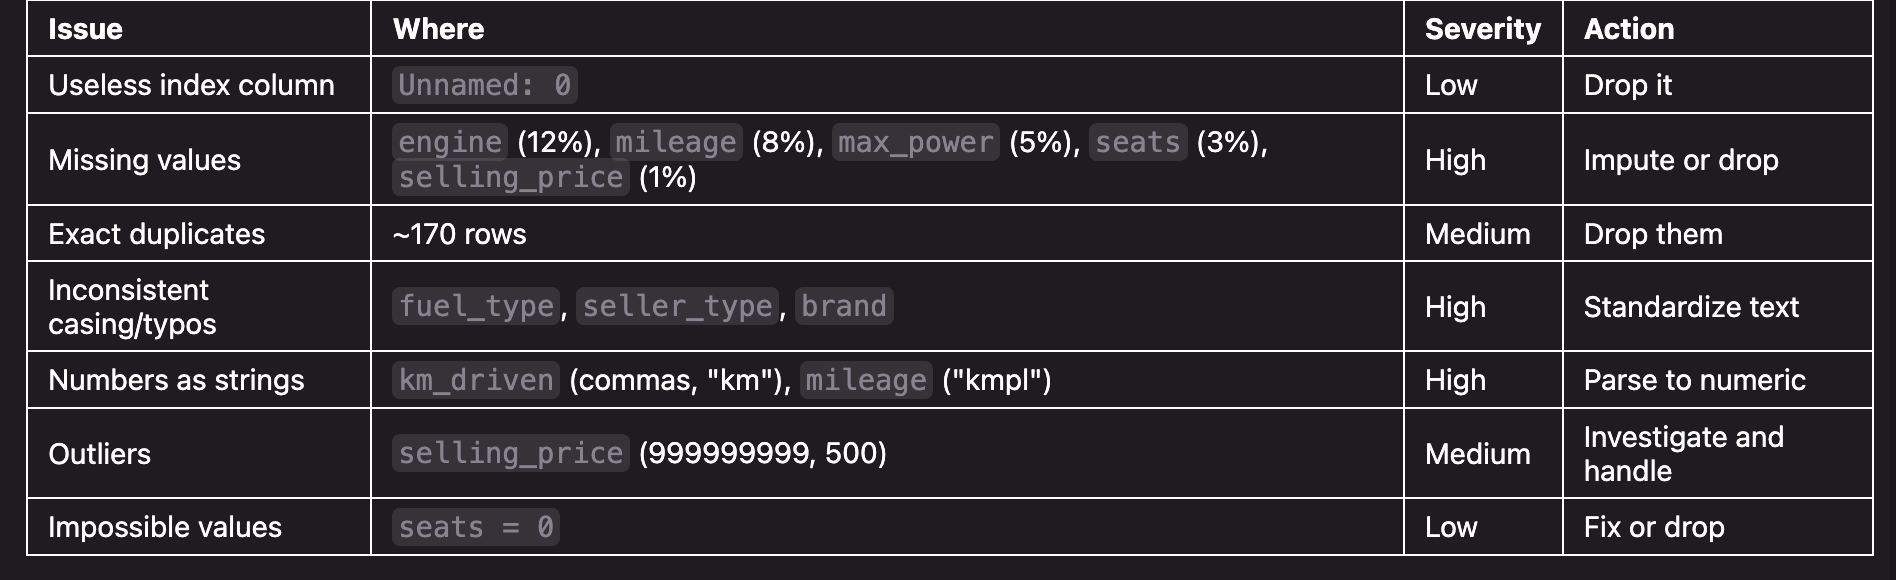

# Start Fixing the data

In [ ]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type',
       'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price'],
      dtype='object')

In [ ]:
df = df.drop(columns=['Unnamed: 0'])
df.head(5)

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.000000,83.800000,5.000000,575000.000000
1,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.000000,67.040000,5.000000,435000.000000
2,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.000000,117.600000,5.000000,875000.000000
3,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.000000,NaN,8.000000,925000.000000
4,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.000000,140.000000,7.000000,1175000.000000


In [ ]:
print(f"Unique valyes before cleaning: {df['brand'].nunique()}")

df['brand'] = df['brand'].str.strip()
print(f"Unique valyes After cleaning: {df['brand'].nunique()}")

print(df['brand'].value_counts())

Unique valyes before cleaning: 80
Unique valyes After cleaning: 32
brand
Maruti           5077
Hyundai          3025
Honda            1508
Mahindra         1031
Toyota            806
Ford              802
Volkswagen        634
Renault           550
BMW               443
Tata              435
Mercedes-Benz     339
Skoda             338
Audi              196
Datsun            172
Jaguar             61
Land Rover         51
Jeep               42
Kia                33
Porsche            22
Volvo              20
MG                 19
Mini               17
Nissan             11
Lexus              10
Isuzu               8
Bentley             3
ISUZU               2
Maserati            2
Ferrari             1
Mercedes-AMG        1
Force               1
Rolls-Royce         1
Name: count, dtype: int64
